## 2.8 양자 몬테카를로 방법 (Quantum Monte Carlo Methods)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 간단한 양자 회로 정의
num_qubits = 4
qc = QuantumCircuit(num_qubits)

In [3]:
# 회로를 중첩 상태로 초기화
qc.h(range(num_qubits))

In [4]:
# 양자 푸리에 변환 적용
qc.append(QFT(num_qubits), range(num_qubits))

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_206/3270133277.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(num_qubits), range(num_qubits))


In [5]:
# 측정 추가
qc.measure_all()

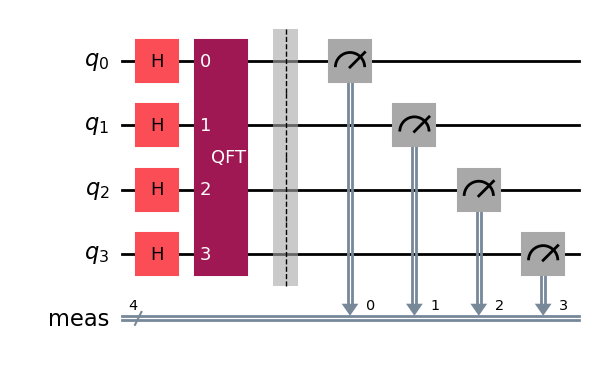

In [6]:
# 원본 회로 그리기
qc.draw(output='mpl')
plt.show()

In [7]:
# AerSimulator 사용
simulator = AerSimulator()

In [8]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

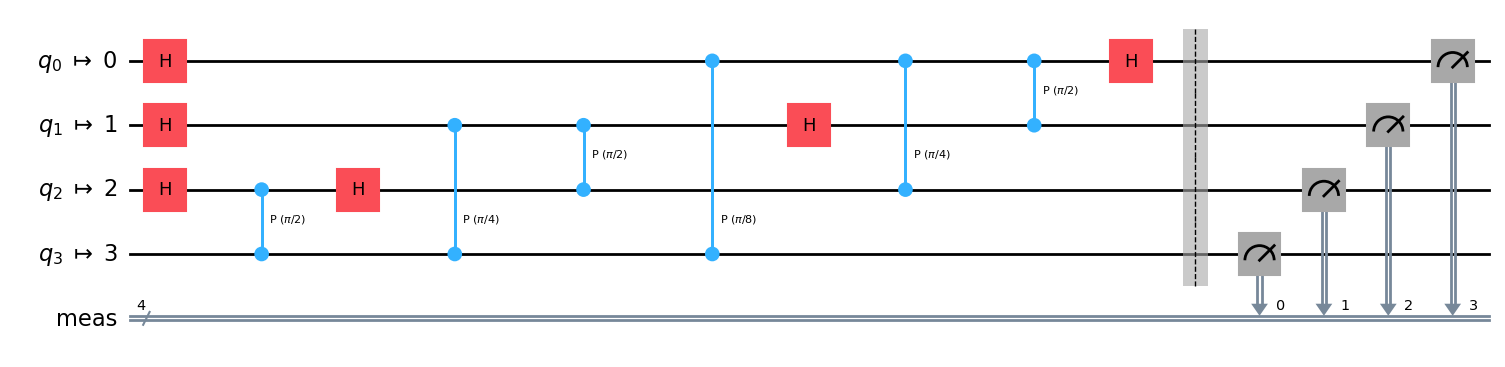

In [9]:
# 트랜스파일된 회로 그리기
compiled_circuit.draw(output='mpl')
plt.show()

In [10]:
# 시뮬레이터에서 회로 실행
job = simulator.run(compiled_circuit)
result = job.result()

In [11]:
# 결과를 얻어 출력
counts = result.get_counts()
print("양자 몬테카를로 시뮬레이션 결과:", counts)

양자 몬테카를로 시뮬레이션 결과: {'0000': 1024}


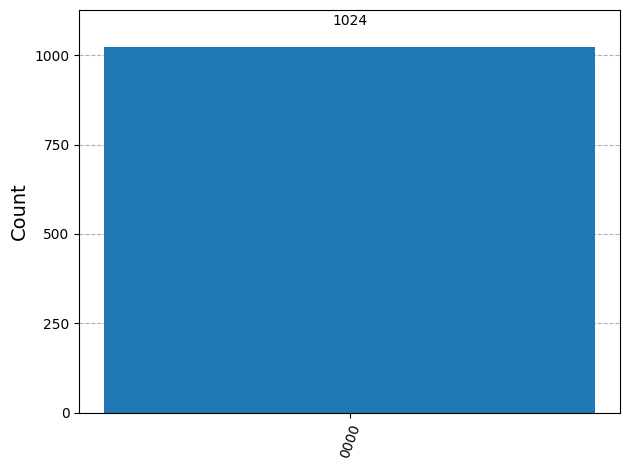

In [12]:
# 결과 시각화
plot_histogram(counts)
plt.show()